In [41]:
# import the usual suspects
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from src.counterfactual_generator import CounterfactualGenerator
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer
from src.utils import load_config,check_file_exists,print_balancing
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score

In [42]:
# let's find the different files we need
config = load_config('config.yaml')
cf_results = config['paths']['counterfactuals']
dt_name = "german_credit"

cf_results

'counterfactuals/'

In [43]:
data_processor = DataProcessor(config=config)
splits = data_processor.load_splits(dt_name)


Loaded feature names from data/processed/german_credit/feature_names.csv
Loaded X_train from data/processed/german_credit/X_train.npz
Loaded y_train from data/processed/german_credit/y_train.npz
Loaded X_test from data/processed/german_credit/X_test.npz
Loaded y_test from data/processed/german_credit/y_test.npz
Loaded X_calibration from data/processed/german_credit/X_calibration.npz
Loaded y_calibration from data/processed/german_credit/y_calibration.npz


In [44]:

model_trainer = ModelTrainer(config)
models = model_trainer.train_model(X_train=splits['X_train'], 
                                    y_train=splits['y_train'], 
                                    X_test=splits['X_test'], 
                                    y_test=splits['y_test'],
                                    dataset_name=dt_name)
print(models.keys())

Processing random_forest for german_credit
Loaded random_forest model from models/german_credit/random_forest.pkl
Loaded existing random_forest model
Processing mlp for german_credit
Loaded mlp model from models/german_credit/mlp.pkl
Loaded existing mlp model
Processing xgboost for german_credit
Loaded xgboost model from models/german_credit/xgboost.pkl
Loaded existing xgboost model
Processing lgbm for german_credit
Loaded lgbm model from models/german_credit/lgbm.pkl
Loaded existing lgbm model
dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm'])


In [45]:
for k in models.keys():
    roc = roc_auc_score(splits['y_test'], models[k].predict_proba(splits['X_test'])[:,1])
    print(f"Model {k} ROC AUC: {roc}")
    acc = accuracy_score(splits['y_test'], models[k].predict(splits['X_test']))
    print(f"Model {k} Accuracy: {acc}")
    f1_ = f1_score(splits['y_test'], models[k].predict(splits['X_test']), average='weighted')
    print(f"Model {k} F1 Score: {f1_}")
    #print(classification_report(splits['y_test'], models[k].predict(splits['X_test'])))
    plot_confusion_ascii(splits['y_test'], models[k].predict(splits['X_test']))
    # print(confusion_matrix(splits['y_test'], models[k].predict(splits['X_test'])))
    print()
    

Model random_forest ROC AUC: 0.7861714285714285
Model random_forest Accuracy: 0.752
Model random_forest F1 Score: 0.7244068721025361
O.
.O


Model mlp ROC AUC: 0.8019047619047619
Model mlp Accuracy: 0.776
Model mlp F1 Score: 0.7687782805429862
@.
 O


Model xgboost ROC AUC: 0.7858285714285714
Model xgboost Accuracy: 0.752
Model xgboost F1 Score: 0.7396257796257796
O.
.O


Model lgbm ROC AUC: 0.7718857142857144
Model lgbm Accuracy: 0.748
Model lgbm F1 Score: 0.7329505393595239
O.
.O




5
checking cf_results_20241203_152712.npz
random_forest
['1', '0']
1
[0 0 1 1 1 1 1 0 0 0 1 0 0 1 0 1 0 1 1 1 0 1 0 1 0 0 1 0 0 1 0 1]
0.5625
0.4375
16
[8.68654741 1.50692963 2.19554489 1.53525556 0.23900065 0.33357664
 1.02971907 2.04911323 1.88296624 1.33750201 6.99944301 3.67168671
 6.28476111 1.36214347 1.21577855 6.27857143]

['0', '1']
0
[0 1 0 1 0 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 0 0 1 0 1]
0.375
0.0
12
[2.2688631  5.04231174 5.92918045 2.41328533 2.08347166 3.12341365
 4.28549467 4.33336026 3.39975987 2.95252177 2.42222836 2.20325666]

0
[0 1 0 0 0 1 0 1 1 1 1 1 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 1 0 1 1 1]
0.34375
0.5
23
[2.55294759 0.94952083 2.78466552 8.1495074  3.76828891 8.49046645
 7.15011505 3.59130464 6.64100827 8.81041891 3.37605892 4.05272854
 3.84635826 8.18787303 7.1495074  2.9001536  2.47482596 4.55032474
 1.02519006 5.04308818 2.68359495 6.3495074  0.98290874]

['1', '0']
1
[1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 0]
0.875
1.0
4
[2.043

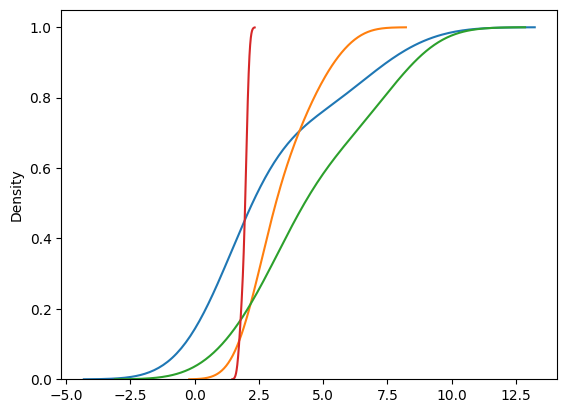

In [117]:
counterfactuals = {k: [] for k in models.keys()}

for k in models.keys():
    # load the counterfactuals
    result_folder_path = os.path.join(cf_results,
                        k+"_dice",
                        dt_name)
    
    results = os.listdir(result_folder_path)
    print(len(results))
    results.sort()
    for r in results:
        print("checking",r) 
        # load the counterfactuals most recent using nupy
        cfs = np.load(os.path.join(result_folder_path, r),allow_pickle=True)#results[0]), allow_pickle=True)
        print(k)
        # cfs is a dictionary with keys "cfs" as the only key (it's an npz file)
        # the value of "cfs" is a np array of dictionaries
        # the keys of the dictionaries are 
        # - instace_idx (the index of the instance in the calibration set)
        # - original_instance (the original class of the instance)
        # - true_class (the true class of the instance)
        for i in range(cfs["cfs"].shape[0]):
            
            # print(cfs["cfs"][0].keys())
            # print(cfs["cfs"][0]["metadata"])
            # print(cfs["cfs"][0]["original_instance"])
            # print(cfs["cfs"][0]["counterfactuals"].target)
            ## just because I don't believe it, let's see the output for the original instance
            ## and check if the model is predicting the class (even to check what true_class is)
            ## then we can check the counterfactuals and see if the model is predicting the opposite class
            ## and if it aligns with the "target" attribute of the counterfactuals
            original_instance = cfs["cfs"][i]["original_instance"]
            pred = models[k].predict(original_instance.values.reshape(1,-1))[0]
            pred_pr = models[k].predict_proba(original_instance.values.reshape(1,-1))
            true_class = cfs["cfs"][i]["true_class"].values[0]
            if not pred == true_class:
                print(str([str(e) for e in [pred,true_class]]))
                assert pred == np.argmax(pred_pr),"WROOONG"

            # now predict the counterfactuals
            to_pred = cfs["cfs"][i]["counterfactuals"].values[:,:-1]
            cf_pred = models[k].predict(to_pred)
            print(pred)
            print(cf_pred)
            print((cfs["cfs"][i]["counterfactuals"].target.values!=cf_pred).sum()/32)
            print((cfs["cfs"][i]["counterfactuals"].target.values!=pred).sum()/32)
            print((cf_pred!=pred).sum())
            # take only the true counterfactuals
            true_cf = cfs["cfs"][i]["counterfactuals"].target.values!=pred
            true_cf = cf_pred!=pred

            # use this to obtain the counterfactuals
            original_instances = cfs["cfs"][i]["counterfactuals"].values[true_cf,:-1]
            not_good_cf = cfs["cfs"][i]["counterfactuals"].values[~true_cf,:-1]# use tilde: ~true_cf
            for ocf in original_instances:
                assert models[k].predict(ocf.reshape(1,-1))[0] != pred
            for ngcf in not_good_cf:
                assert models[k].predict(ngcf.reshape(1,-1))[0] == pred

            distancies = np.linalg.norm(original_instances - cfs["cfs"][i]["original_instance"].values,axis=1)
            print(distancies)
            sns.kdeplot(distancies,cumulative=True)
            print()
            #print(accuracy_score(cf_pred,cfs["cfs"][i]["counterfactuals"].target))
        break
    break
plt.show()
            
            


